# Análise exploratória
## Ativo - ITUB4

In [5]:
# Importanto bibliotecas necessárias
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [6]:
# Definindo o caminho para os dados
PATH = "/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/database/processed/ITUB4_processed.csv"

In [7]:
# Importando o dataset
df = pd.read_csv(PATH, index_col="Date", parse_dates=True)

df.head()

,Close,High,Low,Open,Volume,EMA_60
Date,,,,,,
2021-05-11,18.025209,18.141169,17.857713,17.870598,28633629,18.025209
2021-05-12,17.761089,17.909260,17.638688,17.844837,26098428,18.016550
2021-05-13,18.276453,18.405297,17.761080,17.786849,48363464,18.025071
2021-05-14,18.682310,18.798270,18.257127,18.463277,50573834,18.046620
2021-05-17,18.669437,18.701647,18.276464,18.598573,42125619,18.067040


## Análise 01 - Série Histórica de preços e volumes

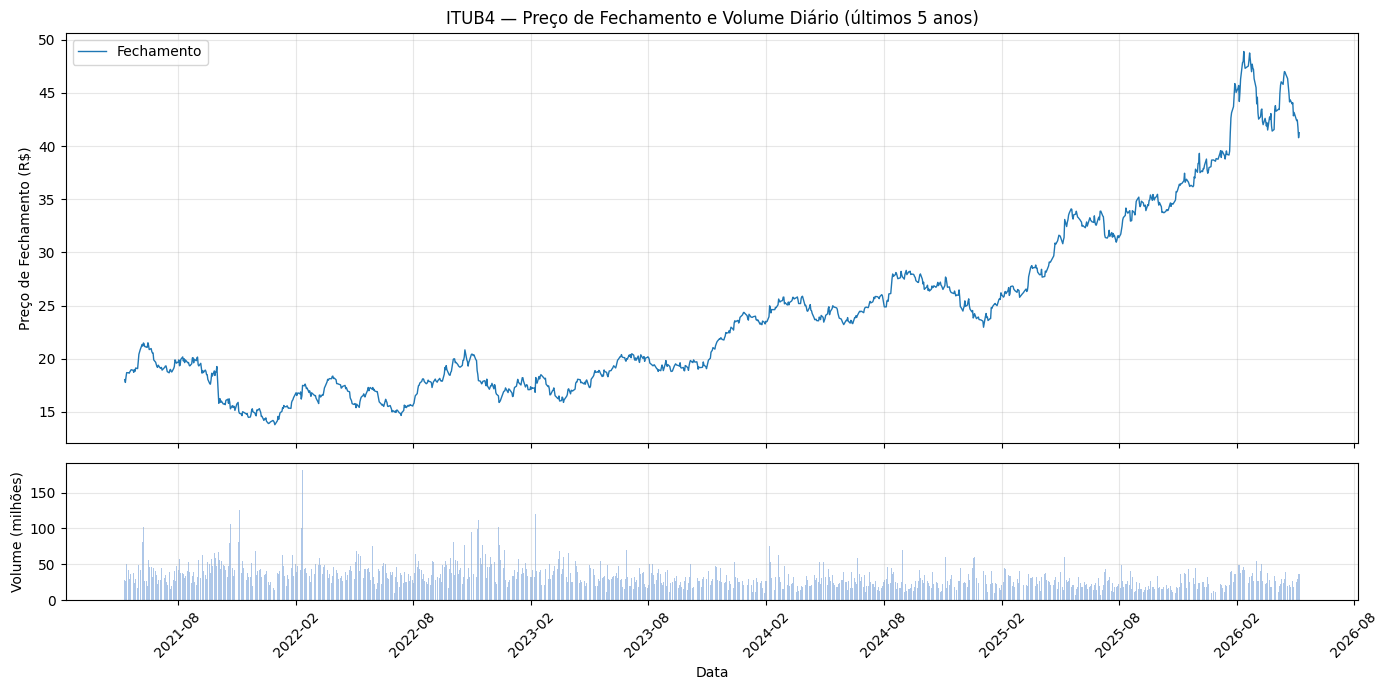

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(df.index, df["Close"], color="#1f77b4", linewidth=1.0, label="Fechamento")
ax1.set_ylabel("Preço de Fechamento (R$)")
ax1.set_title("ITUB4 — Preço de Fechamento e Volume Diário (últimos 5 anos)")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)

ax2.bar(df.index, df["Volume"] / 1e6, color="#aec7e8", width=1.0)
ax2.set_ylabel("Volume (milhões)")
ax2.set_xlabel("Data")
ax2.grid(alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

plt.tight_layout()
#plt.savefig("data/figures/01_preco_volume.png", dpi=300, bbox_inches="tight")
plt.show()

# Análise 02 - Retornos diários logarítmicos

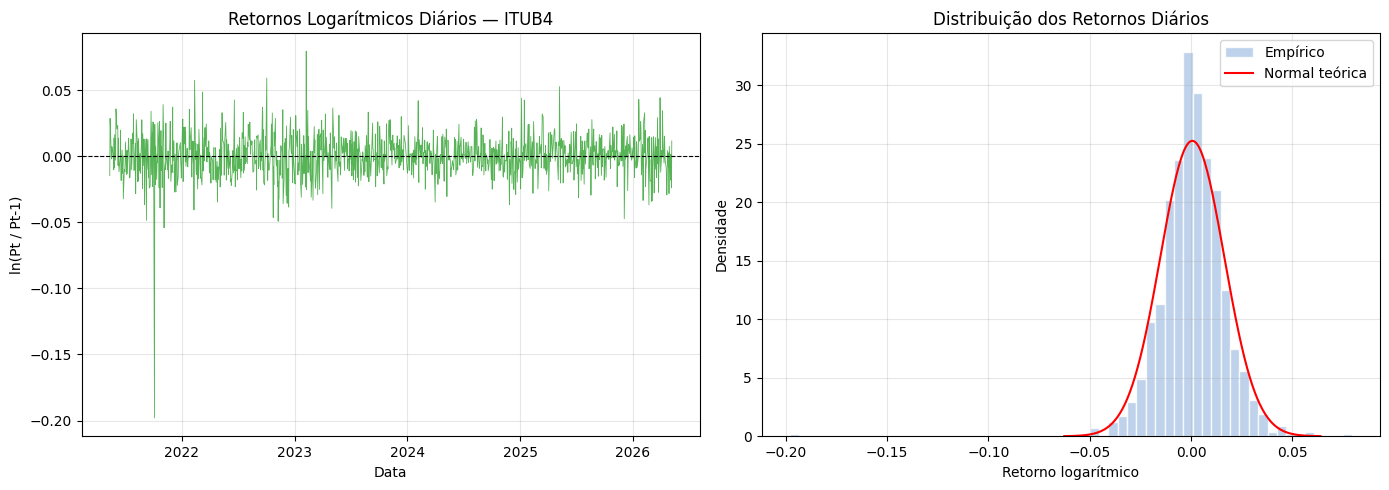

count    1245.000000
mean        0.000665
std         0.015806
min        -0.198015
25%        -0.008154
50%         0.000606
75%         0.009832
max         0.079447
Name: log_return, dtype: float64
Curtose: 20.4894
Assimetria: -1.4444


In [9]:
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Série temporal dos retornos
axes[0].plot(df.index, df["log_return"], color="#2ca02c", linewidth=0.6, alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Retornos Logarítmicos Diários — ITUB4")
axes[0].set_ylabel("ln(Pt / Pt-1)")
axes[0].set_xlabel("Data")
axes[0].grid(alpha=0.3)

# Histograma com curva normal sobreposta
from scipy.stats import norm

mu, sigma = df["log_return"].dropna().mean(), df["log_return"].dropna().std()
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)
axes[1].hist(df["log_return"].dropna(), bins=60, density=True,
             color="#aec7e8", edgecolor="white", alpha=0.8, label="Empírico")
axes[1].plot(x, norm.pdf(x, mu, sigma), "r-", linewidth=1.5, label="Normal teórica")
axes[1].set_title("Distribuição dos Retornos Diários")
axes[1].set_xlabel("Retorno logarítmico")
axes[1].set_ylabel("Densidade")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("data/figures/02_retornos_diarios.png", dpi=300, bbox_inches="tight")
plt.show()

# Estatísticas resumidas
print(df["log_return"].describe())
print(f"Curtose: {df['log_return'].dropna().kurt():.4f}")
print(f"Assimetria: {df['log_return'].dropna().skew():.4f}")

# Análise 03 - Médias móveis sobrepostas ao preço 

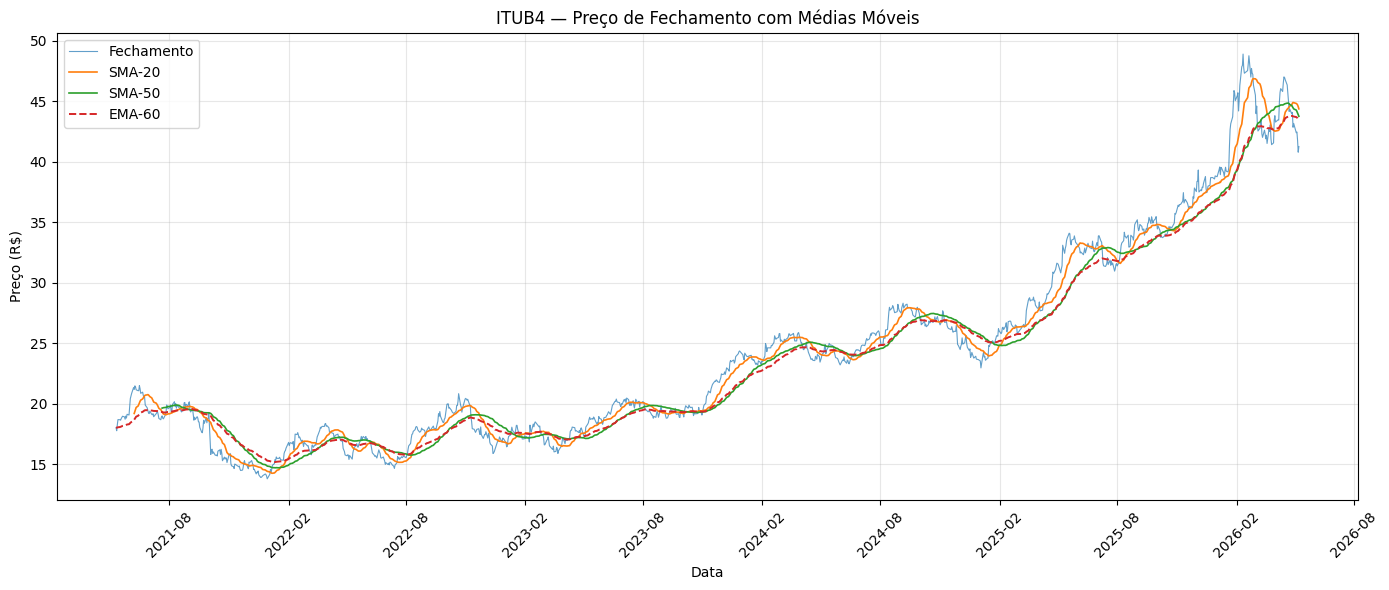

In [10]:
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df["Close"],  color="#1f77b4", linewidth=0.8, alpha=0.7, label="Fechamento")
ax.plot(df.index, df["SMA_20"], color="#ff7f0e", linewidth=1.2, label="SMA-20")
ax.plot(df.index, df["SMA_50"], color="#2ca02c", linewidth=1.2, label="SMA-50")
ax.plot(df.index, df["EMA_60"], color="#d62728", linewidth=1.4, linestyle="--", label="EMA-60")

ax.set_title("ITUB4 — Preço de Fechamento com Médias Móveis")
ax.set_ylabel("Preço (R$)")
ax.set_xlabel("Data")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

plt.tight_layout()
#plt.savefig("data/figures/03_medias_moveis.png", dpi=300, bbox_inches="tight")
plt.show()

# Análise 04 - Mapa de calor de correlções ( Pearson )

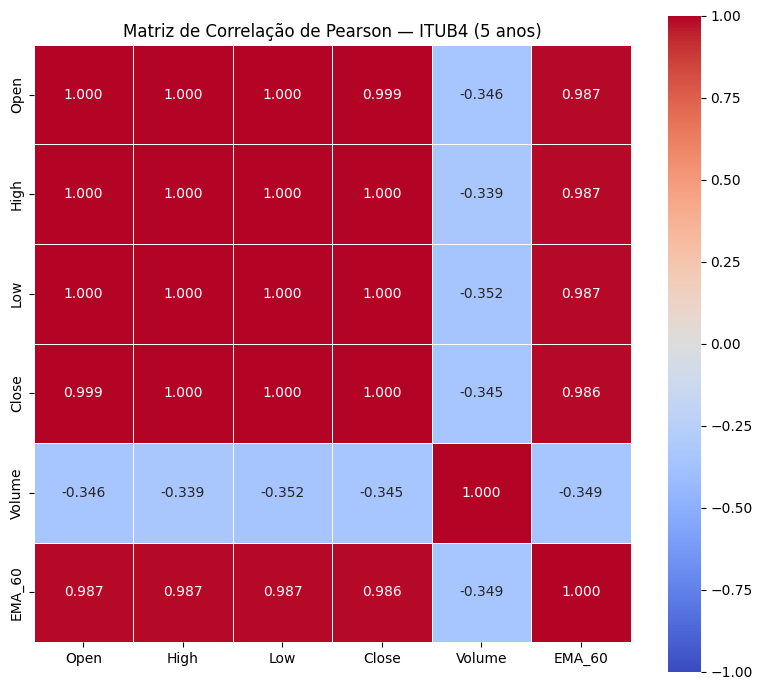

            Open      High       Low     Close    Volume    EMA_60
Open    1.000000  0.999636  0.999648  0.999198 -0.346255  0.987190
High    0.999636  1.000000  0.999658  0.999698 -0.338881  0.986886
Low     0.999648  0.999658  1.000000  0.999685 -0.352178  0.986926
Close   0.999198  0.999698  0.999685  1.000000 -0.344592  0.986309
Volume -0.346255 -0.338881 -0.352178 -0.344592  1.000000 -0.349306
EMA_60  0.987190  0.986886  0.986926  0.986309 -0.349306  1.000000


In [11]:
features = ["Open", "High", "Low", "Close", "Volume", "EMA_60"]
corr_matrix = df[features].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # mostra triângulo inferior

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Matriz de Correlação de Pearson — ITUB4 (5 anos)")
plt.tight_layout()
#plt.savefig("data/figures/04_correlacao_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print(corr_matrix)

# Análise 05 - Identificação visual de períodos atípicos

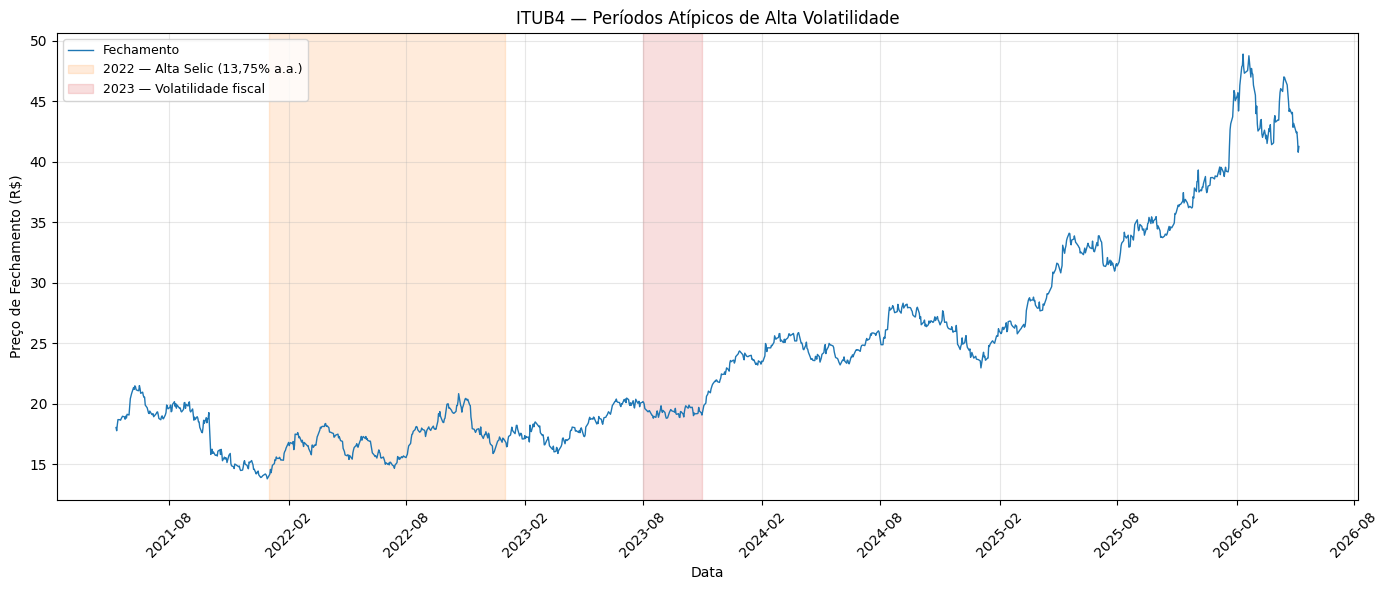

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df["Close"], color="#1f77b4", linewidth=1.0, label="Fechamento")

# Definir períodos atípicos dentro do recorte de 5 anos
# (ajuste as datas conforme o período real do download)
atypical_periods = [
    ("2022-01-01", "2022-12-31", "#ff7f0e", "2022 — Alta Selic (13,75% a.a.)"),
    ("2023-08-01", "2023-10-31", "#d62728", "2023 — Volatilidade fiscal"),
]

for start, end, color, label in atypical_periods:
    # Verificar se o período está dentro do range do df
    start_dt = pd.Timestamp(start)
    end_dt = pd.Timestamp(end)
    if start_dt >= df.index[0] and end_dt <= df.index[-1]:
        ax.axvspan(start_dt, end_dt, alpha=0.15, color=color, label=label)

ax.set_title("ITUB4 — Períodos Atípicos de Alta Volatilidade")
ax.set_ylabel("Preço de Fechamento (R$)")
ax.set_xlabel("Data")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

plt.tight_layout()
#plt.savefig("data/figures/05_periodos_atipicos.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
summary = df[["Open", "High", "Low", "Close", "Volume", "EMA_60"]].describe()
print(summary.to_string())

              Open         High          Low        Close        Volume       EMA_60
count  1246.000000  1246.000000  1246.000000  1246.000000  1.246000e+03  1246.000000
mean     24.055424    24.308724    23.807341    24.058196  3.281702e+07    23.456719
std       8.064471     8.126628     7.996774     8.061812  1.613884e+07     7.350238
min      13.939864    14.020221    13.757063    13.783374  6.695412e+06    15.163748
25%      17.832713    18.014622    17.639912    17.819016  2.197825e+07    17.598304
50%      21.147197    21.402212    20.892178    21.196101  2.941472e+07    19.551173
75%      27.572046    27.884135    27.382942    27.635321  4.022309e+07    26.798663
max      48.588397    49.202568    48.142637    48.905392  1.820390e+08    43.791737
